In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, r2_score
import tensorflow as tf
from statsmodels.tsa.stattools import adfuller



In [65]:
df=pd.read_csv(r'INPUT.csv')
df['DateTime']=pd.to_datetime(df['DateTime'])
df['Date']=pd.to_datetime(df['Date'])
df['Minute']=df['Date'].dt.minute
df['Heure']=df['Date'].dt.hour
df['Jour']=df['DateTime'].dt.day
df['Mois']=df['DateTime'].dt.month
df['Annee']=df['DateTime'].dt.year
df=df.drop(columns=['DateTime','Valeur','Date'])
df=df[['Heure','Minute','Jour','Mois','Annee']+[col for col in df.columns if col not in ['Heure','Minute','Jour','Mois','Annee']]]
df=df.fillna(0)
Y=df['MA']
X=df[[col for col in df.columns if col!='MA']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)  # Scale only X
Y=pd.DataFrame(Y)
# Y['MA_diff']=Y['MA'].diff()
Y=Y.fillna(0)

C:\Users\adamh\AppData\Local\Temp\ipykernel_11048\811542723.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date']=pd.to_datetime(df['Date'])


In [66]:
X['Heure_sin']=np.sin(2*np.pi*X['Heure']/24)
X['Heure_cos']=np.cos(2*np.pi*X['Heure']/24)
X['Minute_sin']=np.sin(2*np.pi*X['Minute']/60)
X['Minute_cos']=np.cos(2*np.pi*X['Minute']/60)
X=X.drop(columns=['Heure','Minute'])

In [67]:
from sklearn.preprocessing import StandardScaler
Xscaler = StandardScaler().set_output(transform="pandas")
Xscaled=Xscaler.fit_transform(X)

In [68]:
Yscaler=StandardScaler().set_output(transform='pandas')
Yscaled=Yscaler.fit_transform(Y)

In [6]:
n=len(X)
m=0.91
Xtrain=X.iloc[0:int(m*n)]
Ytrain=Y.iloc[0:int(m*n)]
Xtest=X.iloc[int(m*n):]
Ytest=Y.iloc[int(m*n):]

from sklearn.ensemble import RandomForestRegressor
from sklearn.datasets import make_regression
regr=RandomForestRegressor(max_depth=8,random_state=0)
regr.fit(Xtrain,Ytrain)
YtestIS=regr.predict(Xtrain)

from sklearn.metrics import r2_score, mean_absolute_error,mean_squared_error
print(r2_score(Ytrain,YtestIS))
print(mean_absolute_error(Ytrain,YtestIS))

YtestOS=regr.predict(Xtest)
print(r2_score(Ytest,YtestOS))
print(mean_absolute_error(Ytest,YtestOS))

c:\Users\adamh\anaconda3\Lib\site-packages\sklearn\base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


0.5435256507287793
47.29282504679833
-0.207681202903234
51.493239177533916


### Importance

In [81]:
n=len(X)
m=0.91
Xtrain=X.iloc[0:int(m*n)]
Ytrain=Y.iloc[0:int(m*n)]
Xtest=X.iloc[int(m*n):]
Ytest=Y.iloc[int(m*n):]

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.datasets import make_regression
regr=GradientBoostingRegressor(
    loss="absolute_error",     # fonction de perte ("squared_error", "absolute_error", "huber", "quantile")
    learning_rate=0.1,        # taux d’apprentissage (plus petit → besoin de + d’arbres)
    n_estimators=100,         # nombre d’arbres
    subsample=1.0,            # fraction d’échantillons par arbre (<1.0 → stochastic boosting)
    criterion="friedman_mse", # fonction de split ("friedman_mse", "squared_error")
    min_samples_split=2,      # min d’échantillons pour diviser un nœud
    min_samples_leaf=1,       # min d’échantillons dans une feuille
    min_weight_fraction_leaf=0.0,  # fraction mini du poids total dans une feuille
    max_depth=3,              # profondeur max des arbres
    min_impurity_decrease=0.0,# seuil de gain d’impureté
    init=None,                # modèle initial (par défaut = constante moyenne)
    random_state=0,           # pour la reproductibilité
    max_features=None,        # nb de features considérés pour chaque split
    alpha=0.9,                # utilisé pour "huber" et "quantile"
    max_leaf_nodes=None,      # nb max de feuilles par arbre
    warm_start=False,         # True → continuer l’entraînement après fit()
    validation_fraction=0.1,  # utilisé avec early_stopping
    n_iter_no_change=None,    # utilisé avec early_stopping
    tol=1e-4,                 # tolérance pour early_stopping
    ccp_alpha=0.0             # paramètre de pruning (post-élagage)
)
regr.fit(Xtrain,Ytrain)
YtestIS=regr.predict(Xtrain)

from sklearn.metrics import r2_score, mean_absolute_error,mean_squared_error
print(r2_score(Ytrain,YtestIS))
print(mean_absolute_error(Ytrain,YtestIS))

YtestOS=regr.predict(Xtest)
print(r2_score(Ytest,YtestOS))
print(mean_absolute_error(Ytest,YtestOS))

from sklearn.inspection import permutation_importance
r = permutation_importance(regr, Xtest, Ytest,
                           n_repeats=30,
                           random_state=0)
r['importances_mean']

c:\Users\adamh\anaconda3\Lib\site-packages\sklearn\ensemble\_gb.py:668: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?


0.10004544544136762
51.38323217052406
-0.1520895620260021
49.97463283746417


array([-3.73201429e-02,  0.00000000e+00,  0.00000000e+00, -6.41393209e-03,
       -3.22163461e-06, -7.70506178e-03,  1.04631605e-02, -4.77219859e-04,
        5.05090986e-03,  3.69095846e-04, -7.93770897e-03,  9.54051932e-03,
       -2.53990600e-05,  7.18298014e-03,  3.85107127e-03,  7.72169112e-03,
        1.80377264e-02, -1.53846539e-03,  0.00000000e+00,  9.25682945e-04])

In [77]:
Xtest

,Jour,Mois,Annee,SPOT,BIOMASS,FOSSIL_GAS,FOSSIL_HARD_COAL,FOSSIL_OIL,HYDRO_PUMPED_STORAGE,HYDRO_RUN_OF_RIVER,HYDRO_WATER_RESERVOIR,NUCLEAR,SOLAR,WASTE,WIND_ONSHORE,conso,Heure_sin,Heure_cos,Minute_sin,Minute_cos
15965,28,11,2024,101.82,169.5,1989.0,293.5,55.5,360.5,2356.5,843.5,24390.5,3078.0,168.0,562.0,56600.0,-0.500000,-0.866025,5.665539e-16,-1.0
15966,28,11,2024,108.93,169.5,2203.5,293.0,55.5,420.0,2468.0,1201.0,24435.5,1918.0,168.0,591.0,58700.0,-0.707107,-0.707107,0.000000e+00,1.0
15967,28,11,2024,108.93,169.5,2203.5,293.0,55.5,420.0,2468.0,1201.0,24435.5,1918.0,168.0,591.0,58100.0,-0.707107,-0.707107,5.665539e-16,-1.0
15968,28,11,2024,117.62,169.5,2389.0,284.0,80.5,1345.0,2676.5,1536.0,24444.5,655.0,167.5,666.5,57000.0,-0.866025,-0.500000,0.000000e+00,1.0
15969,28,11,2024,117.62,169.5,2389.0,284.0,80.5,1345.0,2676.5,1536.0,24444.5,655.0,167.5,666.5,56600.0,-0.866025,-0.500000,5.665539e-16,-1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17539,31,12,2024,50.14,178.0,1045.0,0.0,55.0,262.0,2582.0,734.0,25245.5,0.0,150.5,4083.5,0.0,-0.965926,0.258819,0.000000e+00,1.0
17540,31,12,2024,41.50,177.5,1064.0,0.0,55.0,-405.0,2258.0,695.5,24942.5,0.0,150.0,4196.5,0.0,-0.866025,0.500000,0.000000e+00,1.0
17541,31,12,2024,34.93,178.5,948.0,0.0,54.5,-1042.5,2195.0,242.5,25021.5,0.0,149.0,4359.5,0.0,-0.707107,0.707107,0.000000e+00,1.0
17542,31,12,2024,34.69,177.5,1020.0,0.0,54.5,-938.0,2141.5,238.0,25271.5,0.0,150.0,4482.0,0.0,-0.500000,0.866025,0.000000e+00,1.0


In [82]:
list(r['importances_mean'])

[-0.03732014289916426,
 0.0,
 0.0,
 -0.006413932094292048,
 -3.2216346057841368e-06,
 -0.007705061781000544,
 0.010463160482624767,
 -0.00047721985921545716,
 0.005050909858172566,
 0.0003690958463465455,
 -0.007937708969097313,
 0.009540519315390275,
 -2.5399060009045905e-05,
 0.007182980143381768,
 0.0038510712656446493,
 0.007721691116984804,
 0.018037726395001976,
 -0.001538465393264891,
 0.0,
 0.0009256829452452135]

In [83]:
list(Xtest.columns)

['Jour',
 'Mois',
 'Annee',
 'SPOT',
 'BIOMASS',
 'FOSSIL_GAS',
 'FOSSIL_HARD_COAL',
 'FOSSIL_OIL',
 'HYDRO_PUMPED_STORAGE',
 'HYDRO_RUN_OF_RIVER',
 'HYDRO_WATER_RESERVOIR',
 'NUCLEAR',
 'SOLAR',
 'WASTE',
 'WIND_ONSHORE',
 'conso',
 'Heure_sin',
 'Heure_cos',
 'Minute_sin',
 'Minute_cos']

In [85]:
Graphe=pd.DataFrame({'Exogene':list(Xtest.columns),'Importance':list(r['importances_mean'])})

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19],
 [Text(0, 0, 'Jour'),
  Text(1, 0, 'Mois'),
  Text(2, 0, 'Annee'),
  Text(3, 0, 'SPOT'),
  Text(4, 0, 'BIOMASS'),
  Text(5, 0, 'FOSSIL_GAS'),
  Text(6, 0, 'FOSSIL_HARD_COAL'),
  Text(7, 0, 'FOSSIL_OIL'),
  Text(8, 0, 'HYDRO_PUMPED_STORAGE'),
  Text(9, 0, 'HYDRO_RUN_OF_RIVER'),
  Text(10, 0, 'HYDRO_WATER_RESERVOIR'),
  Text(11, 0, 'NUCLEAR'),
  Text(12, 0, 'SOLAR'),
  Text(13, 0, 'WASTE'),
  Text(14, 0, 'WIND_ONSHORE'),
  Text(15, 0, 'conso'),
  Text(16, 0, 'Heure_sin'),
  Text(17, 0, 'Heure_cos'),
  Text(18, 0, 'Minute_sin'),
  Text(19, 0, 'Minute_cos')])

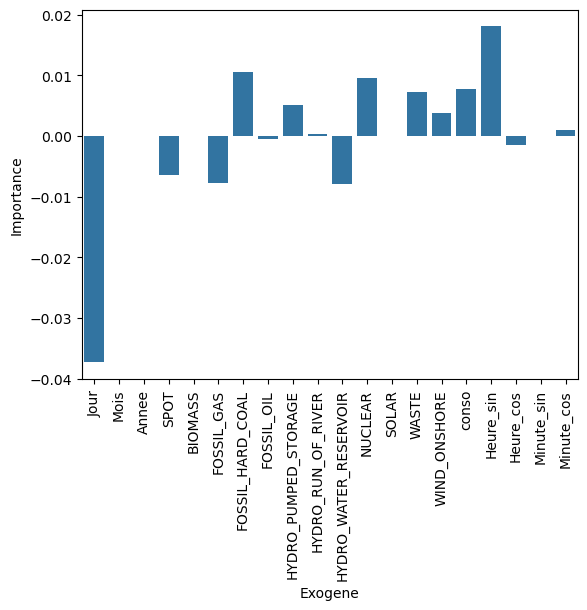

In [87]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.barplot(data=Graphe,x="Exogene",y="Importance")
plt.xticks(rotation=90)   # rotation des labels en 90°


Decallons de 48 lignes les endogenes

In [7]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error,mean_squared_error
from sklearn.ensemble import GradientBoostingRegressor

n=len(X)
m=0.9
step=48
MODEL=[RandomForestRegressor(max_depth=100,random_state=0),GradientBoostingRegressor(random_state=0)]

In [8]:
C1=[]
C2=[]
C3=[]
C4=[]
C5=[]
C6=[]
C7=[]
C8=[]
for model in MODEL:
    for m in [0.5,0.6,0.7,0.8,0.9]:
        Xtrain=X.iloc[0+step:int(m*n)+step]
        Ytrain=Y.iloc[0:int(m*n)]
        Xtest=X.iloc[int(m*n):n+step]
        Ytest=Y.iloc[int(m*n):n]

        regr=model
        regr.fit(Xtrain,Ytrain)
        YtestIS=regr.predict(Xtrain)

        r2IS=(r2_score(Ytrain,YtestIS))
        maeIS=(mean_absolute_error(Ytrain,YtestIS))
        mseIS=mean_squared_error(Ytrain,YtestIS)

        YtestOS=regr.predict(Xtest)
        r2OS=(r2_score(Ytest,YtestOS))
        maeOS=(mean_absolute_error(Ytest,YtestOS))
        mseOS=mean_squared_error(Ytest,YtestOS)
        C1.append(model)
        C2.append(m)
        C3.append(r2IS)
        C4.append(maeIS)
        C5.append(mseIS)
        C6.append(r2OS)
        C7.append(maeOS)
        C8.append(mseOS)

Result = pd.DataFrame({
    'Model': C1,
    'M': C2,
    'R2_IS': C3,
    'MAE_IS': C4,
    'MSE_IS': C5,
    'R2_OS': C6,
    'MAE_OS': C7,
    'MSE_OS': C8
})


c:\Users\adamh\anaconda3\Lib\site-packages\sklearn\base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Users\adamh\anaconda3\Lib\site-packages\sklearn\base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Users\adamh\anaconda3\Lib\site-packages\sklearn\base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Users\adamh\anaconda3\Lib\site-packages\sklearn\base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for

In [9]:
Result

,Model,M,R2_IS,MAE_IS,MSE_IS,R2_OS,MAE_OS,MSE_OS
0,"(DecisionTreeRegressor(max_depth=100, max_feat...",0.5,0.922576,15.522395,1169.501426,-6.289882,188.890173,70128.972473
1,"(DecisionTreeRegressor(max_depth=100, max_feat...",0.6,0.916051,15.298910,1311.470095,-1.781094,88.380776,21551.337609
2,"(DecisionTreeRegressor(max_depth=100, max_feat...",0.7,0.917615,14.512629,1194.555009,-0.500323,75.065533,11934.375581
3,"(DecisionTreeRegressor(max_depth=100, max_feat...",0.8,0.923872,14.119850,1122.088929,-22.495698,132.739016,87453.512081
4,"(DecisionTreeRegressor(max_depth=100, max_feat...",0.9,0.924159,13.536202,1018.250127,-0.454707,60.622187,6472.854653
5,([DecisionTreeRegressor(criterion='friedman_ms...,0.5,0.374663,55.581515,9445.854481,-1.559465,95.651107,24622.156807
6,([DecisionTreeRegressor(criterion='friedman_ms...,0.6,0.323021,55.807446,10575.895603,-1.393250,84.952313,18545.840872
7,([DecisionTreeRegressor(criterion='friedman_ms...,0.7,0.293503,54.706664,10244.018446,-1.472661,89.139986,19668.877287
8,([DecisionTreeRegressor(criterion='friedman_ms...,0.8,0.322194,54.290572,9990.575919,-1.216331,59.550582,8249.423175
9,([DecisionTreeRegressor(criterion='friedman_ms...,0.9,0.288454,52.619050,9553.248152,-0.381069,56.720929,6145.198214


In [71]:
C0=[]
C1=[]
C2=[]
C3=[]
C4=[]
C5=[]
C6=[]
C7=[]
C8=[]
STEP_=[]
STEP=[24,48]
model=model = GradientBoostingRegressor(
    loss="absolute_error",     # fonction de perte ("squared_error", "absolute_error", "huber", "quantile")
    learning_rate=0.1,        # taux d’apprentissage (plus petit → besoin de + d’arbres)
    n_estimators=100,         # nombre d’arbres
    subsample=1.0,            # fraction d’échantillons par arbre (<1.0 → stochastic boosting)
    criterion="friedman_mse", # fonction de split ("friedman_mse", "squared_error")
    min_samples_split=2,      # min d’échantillons pour diviser un nœud
    min_samples_leaf=1,       # min d’échantillons dans une feuille
    min_weight_fraction_leaf=0.0,  # fraction mini du poids total dans une feuille
    max_depth=3,              # profondeur max des arbres
    min_impurity_decrease=0.0,# seuil de gain d’impureté
    init=None,                # modèle initial (par défaut = constante moyenne)
    random_state=0,           # pour la reproductibilité
    max_features=None,        # nb de features considérés pour chaque split
    alpha=0.9,                # utilisé pour "huber" et "quantile"
    max_leaf_nodes=None,      # nb max de feuilles par arbre
    warm_start=False,         # True → continuer l’entraînement après fit()
    validation_fraction=0.1,  # utilisé avec early_stopping
    n_iter_no_change=None,    # utilisé avec early_stopping
    tol=1e-4,                 # tolérance pour early_stopping
    ccp_alpha=0.0             # paramètre de pruning (post-élagage)
)

for n in range(10000,17000,10):
    for step in STEP:
        Xtrain=X.iloc[0:n-step]
        Ytrain=Y.iloc[0:n-step]
        Xtest=X.iloc[n-step:n]
        Ytest=Y.iloc[n-step:n]

        regr=model
        regr.fit(Xtrain,Ytrain)
        YtestIS=regr.predict(Xtrain)

        r2IS=(r2_score(Ytrain,YtestIS))
        maeIS=(mean_absolute_error(Ytrain,YtestIS))
        mseIS=mean_squared_error(Ytrain,YtestIS)

        YtestOS=regr.predict(Xtest)
        r2OS=(r2_score(Ytest,YtestOS))
        maeOS=(mean_absolute_error(Ytest,YtestOS))
        mseOS=mean_squared_error(Ytest,YtestOS)

        naive=list(Y['MA'].iloc[n-step-step:n-step])

        C0.append(n)
        C1.append(model)
        C2.append(m)
        C3.append(r2IS)
        C4.append(maeIS)
        C5.append(mseIS)
        C6.append(r2OS)
        C7.append(maeOS)
        C8.append(mseOS)
        STEP_.append(step)


Result = pd.DataFrame({
'N':C0,
'STEP': STEP_,
'R2_IS': C3,
'MAE_IS': C4,
'MSE_IS': C5,
'R2_OS': C6,
'MAE_OS': C7,
'MSE_OS': C8
})


c:\Users\adamh\anaconda3\Lib\site-packages\sklearn\ensemble\_gb.py:668: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?
c:\Users\adamh\anaconda3\Lib\site-packages\sklearn\ensemble\_gb.py:668: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?
c:\Users\adamh\anaconda3\Lib\site-packages\sklearn\ensemble\_gb.py:668: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?
c:\Users\adamh\anaconda3\Lib\site-packages\sklearn\ensemble\_gb.py:668: DataConversionWarning: A column-vector y was p

In [76]:
Result['MAE_OS'].mean()

45.48289392891967

In [96]:
len(list(YtestOS))

48

In [95]:
len(naive)

48

In [97]:
len(Ytest)

48

In [87]:
mean_absolute_error(Ytest,naive)
mean_absolute_error(Ytest,YtestOS)

64.81066979083776

In [99]:
Graph=pd.DataFrame({'MA_true':Ytest['MA'],'MA_naive':naive,'MA_GB':list(YtestOS)})

Text(0.5, 0, 'heure+')

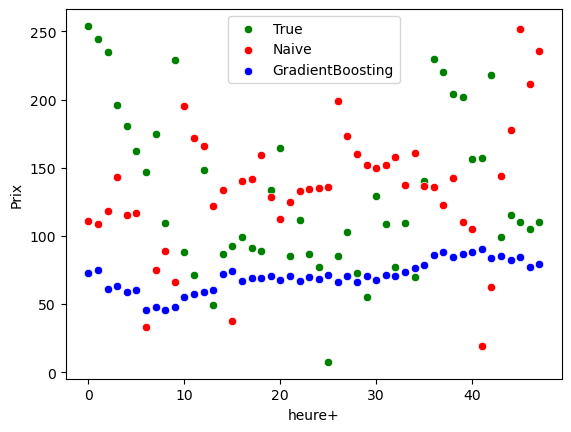

In [111]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.scatterplot(x=Graph.index, y=Graph['MA_true'],color='green',label='True')
sns.scatterplot(x=Graph.index, y=Graph['MA_naive'],color='red',label='Naive')
sns.scatterplot(x=Graph.index, y=Graph['MA_GB'],color='blue',label='GradientBoosting')
plt.ylabel('Prix')
plt.xlabel('heure+')





In [109]:
Graph["Naive-True"]=Graph['MA_naive']-Graph['MA_true']
Graph["GB-TRUE"]=Graph['MA_naive']-Graph['MA_GB']
Graph=Graph.reset_index()

Text(0.5, 0, 'heure+')

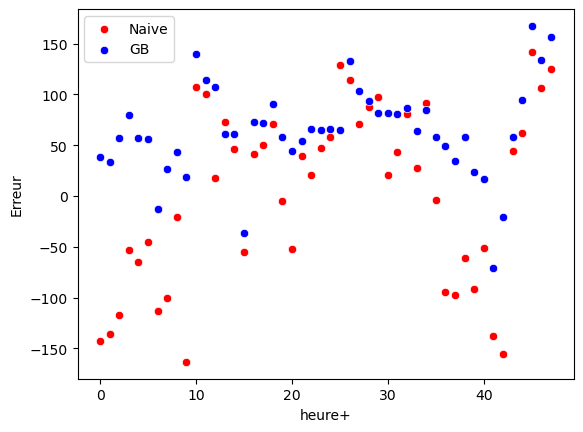

In [110]:
import seaborn as sns
sns.scatterplot(x=Graph.index, y=Graph['Naive-True'],color='red',label='Naive')
sns.scatterplot(x=Graph.index, y=Graph['GB-TRUE'],color='blue',label='GB')
plt.ylabel('Erreur')
plt.xlabel('heure+')



### Distribution des erreurs

In [47]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, r2_score
import tensorflow as tf
from statsmodels.tsa.stattools import adfuller
from sklearn.ensemble import GradientBoostingRegressor



In [48]:
df=pd.read_csv(r'INPUT.csv')
df['DateTime']=pd.to_datetime(df['DateTime'])
df['Date']=pd.to_datetime(df['Date'])
df['Minute']=df['Date'].dt.minute
df['Heure']=df['Date'].dt.hour
df['Jour']=df['DateTime'].dt.day
df['Mois']=df['DateTime'].dt.month
df['Annee']=df['DateTime'].dt.year
df=df.drop(columns=['DateTime','Valeur','Date'])
df=df[['Heure','Minute','Jour','Mois','Annee']+[col for col in df.columns if col not in ['Heure','Minute','Jour','Mois','Annee']]]
df=df.fillna(0)
Y=df['MA']
X=df[[col for col in df.columns if col!='MA']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)  # Scale only X
Y=pd.DataFrame(Y)
# Y['MA_diff']=Y['MA'].diff()
Y=Y.fillna(0)

C:\Users\adamh\AppData\Local\Temp\ipykernel_11048\811542723.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date']=pd.to_datetime(df['Date'])


In [49]:
X['Heure_sin']=np.sin(2*np.pi*X['Heure']/24)
X['Heure_cos']=np.cos(2*np.pi*X['Heure']/24)
X['Minute_sin']=np.sin(2*np.pi*X['Minute']/60)
X['Minute_cos']=np.cos(2*np.pi*X['Minute']/60)
X=X.drop(columns=['Heure','Minute'])

In [50]:
from sklearn.preprocessing import StandardScaler
Xscaler = StandardScaler().set_output(transform="pandas")
Xscaled=Xscaler.fit_transform(X)
Yscaler=StandardScaler().set_output(transform='pandas')
Yscaled=Yscaler.fit_transform(Y)

In [51]:
n=len(X)
m=0.91
Xtrain=X.iloc[0:int(m*n)]
Ytrain=Y.iloc[0:int(m*n)]
Xtest=X.iloc[int(m*n):]
Ytest=Y.iloc[int(m*n):]

from sklearn.ensemble import RandomForestRegressor
from sklearn.datasets import make_regression
regr=RandomForestRegressor(max_depth=8,random_state=0)
regr.fit(Xtrain,Ytrain)
YtestIS=regr.predict(Xtrain)

from sklearn.metrics import r2_score, mean_absolute_error,mean_squared_error
print(r2_score(Ytrain,YtestIS))
print(mean_absolute_error(Ytrain,YtestIS))

YtestOS=regr.predict(Xtest)
print(r2_score(Ytest,YtestOS))
print(mean_absolute_error(Ytest,YtestOS))

c:\Users\adamh\anaconda3\Lib\site-packages\sklearn\base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


0.5435256507287793
47.29282504679833
-0.207681202903234
51.493239177533916


In [52]:
C0=[]
C1=[]
C2=[]
C3=[]
C4=[]
C5=[]
C6=[]
C7=[]
C8=[]
STEP_=[]
C9=[]
STEP=[24,48]
model=model = GradientBoostingRegressor(
    loss="absolute_error",     # fonction de perte ("squared_error", "absolute_error", "huber", "quantile")
    learning_rate=0.1,        # taux d’apprentissage (plus petit → besoin de + d’arbres)
    n_estimators=10,         # nombre d’arbres
    subsample=1.0,            # fraction d’échantillons par arbre (<1.0 → stochastic boosting)
    criterion="friedman_mse", # fonction de split ("friedman_mse", "squared_error")
    min_samples_split=2,      # min d’échantillons pour diviser un nœud
    min_samples_leaf=1,       # min d’échantillons dans une feuille
    min_weight_fraction_leaf=0.0,  # fraction mini du poids total dans une feuille
    max_depth=3,              # profondeur max des arbres
    min_impurity_decrease=0.0,# seuil de gain d’impureté
    init=None,                # modèle initial (par défaut = constante moyenne)
    random_state=0,           # pour la reproductibilité
    max_features=None,        # nb de features considérés pour chaque split
    alpha=0.9,                # utilisé pour "huber" et "quantile"
    max_leaf_nodes=None,      # nb max de feuilles par arbre
    warm_start=False,         # True → continuer l’entraînement après fit()
    validation_fraction=0.1,  # utilisé avec early_stopping
    n_iter_no_change=None,    # utilisé avec early_stopping
    tol=1e-4,                 # tolérance pour early_stopping
    ccp_alpha=0.0             # paramètre de pruning (post-élagage)
)

for n in range(10000,17000,10):
    for step in STEP:
        Xtrain=X.iloc[0:n-step]
        Ytrain=Y.iloc[0:n-step]
        Xtest=X.iloc[n-step:n]
        Ytest=Y.iloc[n-step:n]

        regr=model
        regr.fit(Xtrain,Ytrain)
        YtestIS=regr.predict(Xtrain)

        r2IS=(r2_score(Ytrain,YtestIS))
        maeIS=(mean_absolute_error(Ytrain,YtestIS))
        mseIS=mean_squared_error(Ytrain,YtestIS)

        YtestOS=regr.predict(Xtest)
        r2OS=(r2_score(Ytest,YtestOS))
        maeOS=(mean_absolute_error(Ytest,YtestOS))
        mseOS=mean_squared_error(Ytest,YtestOS)

        naive=list(Y['MA'].iloc[n-step-step:n-step])
        maeOS_naive=(mean_absolute_error(Ytest,naive))

        C0.append(n)
        C1.append(model)
        C2.append(m)
        C3.append(r2IS)
        C4.append(maeIS)
        C5.append(mseIS)
        C6.append(r2OS)
        C7.append(maeOS)
        C8.append(mseOS)
        STEP_.append(step)
        C9.append(maeOS_naive)


Result = pd.DataFrame({
'N':C0,
'STEP': STEP_,
'R2_IS': C3,
'MAE_IS': C4,
'MSE_IS': C5,
'R2_OS': C6,
'MAE_OS': C7,
'MSE_OS': C8,
'MAE_Naive':C9
})


c:\Users\adamh\anaconda3\Lib\site-packages\sklearn\ensemble\_gb.py:668: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?
c:\Users\adamh\anaconda3\Lib\site-packages\sklearn\ensemble\_gb.py:668: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?
c:\Users\adamh\anaconda3\Lib\site-packages\sklearn\ensemble\_gb.py:668: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?
c:\Users\adamh\anaconda3\Lib\site-packages\sklearn\ensemble\_gb.py:668: DataConversionWarning: A column-vector y was p

In [53]:
Result

,N,STEP,R2_IS,MAE_IS,MSE_IS,R2_OS,MAE_OS,MSE_OS,MAE_Naive
0,10000,24,0.053973,61.340768,15229.704970,0.020029,58.015347,7324.048987,88.695417
1,10000,48,0.053111,61.418810,15260.933210,0.085677,59.792132,6987.502006,30.526875
2,10010,24,0.054389,61.335028,15221.457953,-0.946052,37.563917,2128.930274,77.261250
3,10010,48,0.053240,61.401766,15247.609363,0.076257,60.137074,7038.429957,30.872083
4,10020,24,0.054215,61.296229,15214.640855,-0.308781,43.708663,2614.671279,81.806667
...,...,...,...,...,...,...,...,...,...
1395,16970,48,0.048690,55.688225,12134.028605,-1.311317,71.997582,7748.091785,71.815833
1396,16980,24,0.050028,55.734605,12109.530369,-0.509791,40.481945,3336.037261,85.962917
1397,16980,48,0.049874,55.694692,12114.443546,-0.979473,68.864262,7951.813186,73.821042
1398,16990,24,0.051367,55.619348,12086.035237,-0.778575,57.620338,5653.938004,86.009583


<Axes: xlabel='Count', ylabel='MAE_OS'>

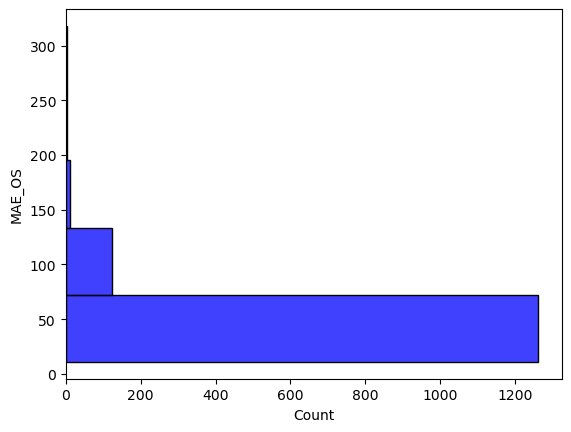

In [54]:
import seaborn as sns
sns.histplot(data=Result,y="MAE_OS",color="blue",bins=5)

<Axes: xlabel='Count', ylabel='MAE_Naive'>

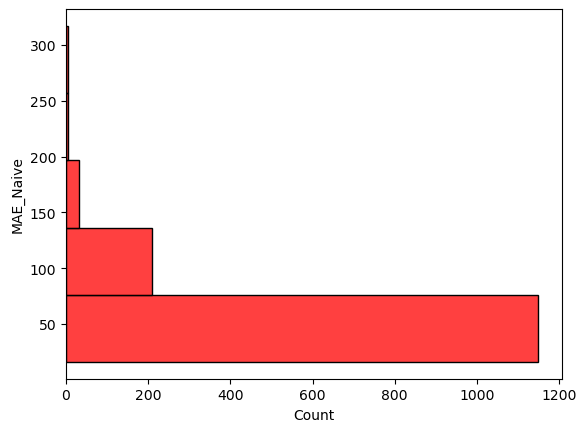

In [55]:
sns.histplot(data=Result,y="MAE_Naive",color="red",bins=5)

<Axes: xlabel='MAE', ylabel='Count'>

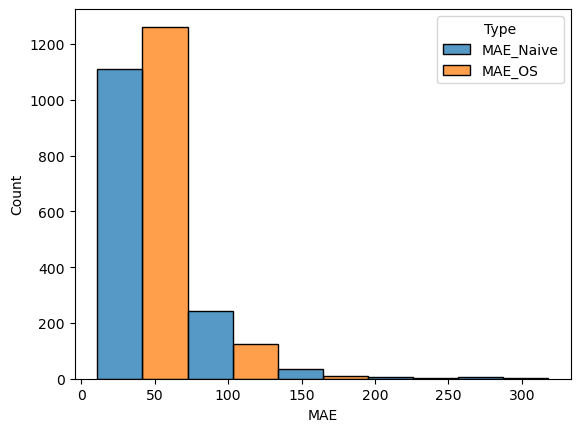

In [62]:
sns.histplot(data=Result.melt(value_vars=["MAE_Naive","MAE_OS"], 
                              var_name="Type", value_name="MAE"),
             x="MAE", hue="Type", bins=5, multiple="dodge")

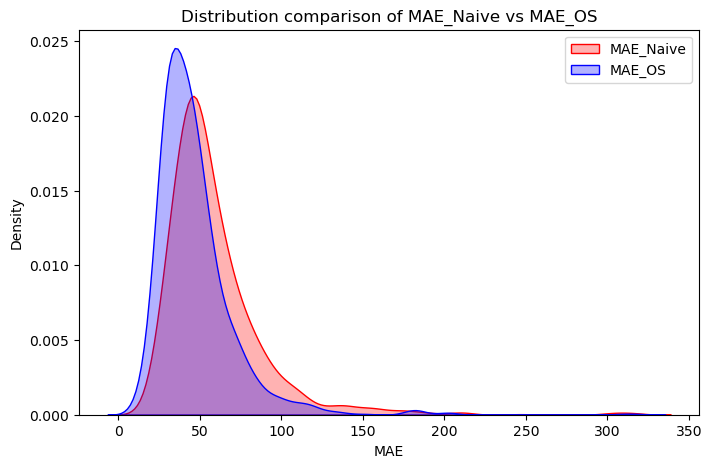

In [63]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.kdeplot(data=Result, x="MAE_Naive", color="red", label="MAE_Naive", fill=True, alpha=0.3)
sns.kdeplot(data=Result, x="MAE_OS", color="blue", label="MAE_OS", fill=True, alpha=0.3)

plt.xlabel("MAE")
plt.ylabel("Density")
plt.title("Distribution comparison of MAE_Naive vs MAE_OS")
plt.legend()
plt.show()


In [60]:
Result['MAE_Naive'].mean()

58.82226517857143

In [61]:
Result['MAE_OS'].mean()

46.92278508983096

In [56]:
Y['MA_Naive'] = Y['MA'] - Y['MA'].shift(48).fillna(method='bfill')


C:\Users\adamh\AppData\Local\Temp\ipykernel_11048\3829970333.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  Y['MA_Naive'] = Y['MA'] - Y['MA'].shift(48).fillna(method='bfill')


In [57]:
Result['MAE_OS'].mean()

46.92278508983096

In [58]:
Y['MA_Naive_error']=Y['MA']-Y['MA_Naive']

<Axes: xlabel='Count', ylabel='MA_Naive_error'>

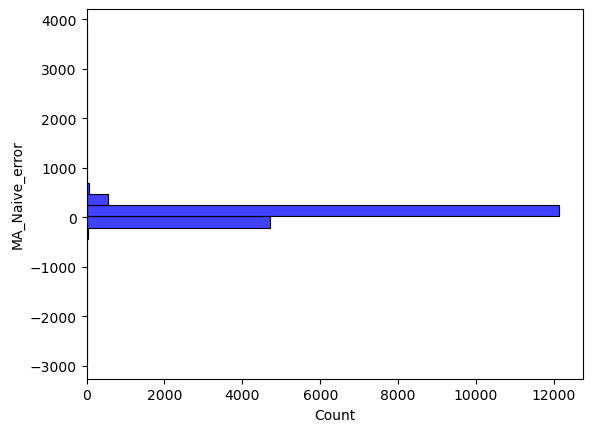

In [59]:
sns.histplot(data=Y,y="MA_Naive_error",color="blue",bins=30)